# ROMMA Scraping again

Almost everyone knows that you can get time series by scraping pages.


https://www.infoclimat.fr/climatologie/normales-records/1981-2010/grenoble-lvd/valeurs/38538002.html

http://romma.fr/station_24.php?id=4&tempe=1

In [27]:

# one of the package managers uv or pip or conda has f*cked up my PATH\n",
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")
 

import matplotlib.pyplot as plt
import numpy as np 
import re
import time

import requests
import html

from scipy import stats

## Extracting the data arrays

The good stuff is hiden in a frame but is easily accesible

In [28]:
import re
import numpy as np

def html2arrays(txt):
    """
    Parses JavaScript arrays from raw ROMMA HTML data, converts them 
    to NumPy arrays, and aligns missing data to a fixed 10-minute grid.
    """
    # Replace JSON-style nulls with string nans for easier float conversion
    txt = re.sub(r'null', 'nan', txt)

    # Regex to capture variable names and their array contents inside brackets
    pattern = re.compile(r'var\s+([\w\s]*?)array\s*=\s*.*?\[(.*?)\]', re.DOTALL)
    data = dict(pattern.findall(txt))

    fields = ['time', 'temp', 'pluie', 'intenspluie', 'pression', 
              'hum', 'rad', 'rafale', 'vent', 'ventdir']
    
    arrays = {}
    index = None  # Initialize grid index variable

    for key in fields:     
        if key not in data:
            print(f"Warning: Key '{key}' not found in scraped data.")
            continue
            
        try:
            # Safely split strings and convert to float/NaN
            raw_vals = data[key].split(',')
            parsed_vals = [float(x) if x.strip() != '' else float('nan') for x in raw_vals]
            arrays[key] = np.array(parsed_vals)
            
            # Time synchronization and hole-fixing pipeline
            if key == 'time':
                # Convert timestamps to 10-minute grid indices (600,000 ms)
                index = (arrays['time'] - arrays['time'][0]) / 600000  
                index = index.astype(np.int32)
                index = np.clip(index, 0, 4463)  # Safe bounding to max array size
            
            elif index is not None:
                # Map irregular time series data onto a fixed-size baseline array
                fixed_grid = np.zeros(4464)
                fixed_grid[index] = arrays[key]
                arrays[key] = fixed_grid
                
        except Exception as e:
            print(f"Error processing field '{key}': {e}")
            
    return arrays
    
def get_station(ref_num=6):       
    base_url = 'https://www.romma.fr'
    url = base_url + '/frame_station24.php?id_station={}&tempe=1&humi=&pluie=&vent=&pressure=&rayonnement=&neige='

    headers = {'User-Agent': "Mozilla/5.0 (X11; CrOS x86_64 13099.62.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/84.0.4147.83 Safari/537.36",
             'Host': 'romma.fr',
            'Referer': f'https://www.romma.fr/station_24.php?id={ref_num}&tempe=1'}
    #30/5/2026 I changed Referer
    
    print(f'Fetching station {ref_num}')
    
    r = requests.post(url.format(ref_num) , 
                     headers=headers)
    
    return r.text


data = {}
for k in [1,3,5,44,4,552]: 
    tt = get_station(ref_num=k)
    meteo = html2arrays(tt)
    time.sleep(10)
    data[k] = meteo


Fetching station 1
Fetching station 3
Fetching station 5
Fetching station 44
Fetching station 4
Fetching station 552


In [29]:
import re
import numpy as np

def html2arrays(txt):
    """
    Parses JavaScript arrays from raw HTML data, converts them 
    to NumPy arrays, and perfectly aligns all variables to a 
    clean, shared 10-minute time grid.
    """
    # Replace JSON-style nulls with string nans for uniform parsing
    txt = re.sub(r'null', 'nan', txt)

    # Regex to extract variable array matches
    pattern = re.compile(r'var\s+([\w\s]*?)array\s*=\s*.*?\[(.*?)\]', re.DOTALL)
    data = dict(pattern.findall(txt))

    fields = ['time', 'temp', 'pluie', 'intenspluie', 'pression', 
              'hum', 'rad', 'rafale', 'vent', 'ventdir']
    
    raw_arrays = {}

    # Step 1: Extract and convert all raw text blocks into flat arrays
    for key in fields:     
        if key in data:
            raw_vals = data[key].split(',')
            parsed_vals = [float(x) if x.strip() != '' else float('nan') for x in raw_vals]
            raw_arrays[key] = np.array(parsed_vals)
        else:
            print(f"Warning: Key '{key}' missing from raw scraped data.")
            raw_arrays[key] = np.array([])

    # Step 2: Establish the absolute grid timeline boundary using 'time'
    if 'time' not in raw_arrays or raw_arrays['time'].size == 0:
        raise ValueError("Critical Error: 'time' array is missing or empty. Cannot align grid.")

    # Calculate absolute indices relative to the month start segment
    time_axis = raw_arrays['time']
    grid_indices = ((time_axis - time_axis[0]) / 600000).astype(np.int32)
    grid_indices = np.clip(grid_indices, 0, 4463)  # Hard cap at max grid capacity

    # Step 3: Construct synchronized arrays of uniform size (4464,)
    aligned_dataset = {}
    
    # Process the time axis first to form the solid anchor
    time_grid = np.zeros(4464)
    time_grid[grid_indices] = time_axis
    aligned_dataset['time'] = time_grid

    # Process all subsequent weather data points using the exact same mapping
    for key in fields:
        if key == 'time':
            continue
            
        # Pre-populate with NaNs so missing station entries don't skew as zero values
        feature_grid = np.full(4464, np.nan)
        
        raw_vals = raw_arrays[key]
        if raw_vals.size > 0:
            # Safely slice or map raw lengths onto the absolute target slots
            limit = min(len(grid_indices), len(raw_vals))
            feature_grid[grid_indices[:limit]] = raw_vals[:limit]
            
        aligned_dataset[key] = feature_grid
            
    return aligned_dataset


data = {}
for k in [1,3,5,44,4,552]: 
    tt = get_station(ref_num=k)
    meteo = html2arrays(tt)
    time.sleep(2)
    data[k] = meteo


Fetching station 1
Fetching station 3
Fetching station 5
Fetching station 44
Fetching station 4
Fetching station 552


In [3]:
? time.sleep


Docstring:
sleep(seconds)

Delay execution for a given number of seconds.  The argument may be
a floating point number for subsecond precision.
Type:      builtin_function_or_method

I think this is a request in Chrome developper capture to get the User-Agent

In [27]:
GET /frame_station24.php?id_station=4&tempe=1&humi=&pluie=&vent=&pressure=&rayonnement=&neige= HTTP/1.1
Host: www.romma.fr
Connection: keep-alive
Upgrade-Insecure-Requests: 1
DNT: 1
User-Agent: Mozilla/5.0 (X11; CrOS x86_64 13505.27.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/87.0.4280.38 Safari/537.36
Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9
Sec-Fetch-Site: same-origin
Sec-Fetch-Mode: navigate
Sec-Fetch-Dest: iframe
Referer: https://www.romma.fr/station_24.php?id=4&tempe=1
Accept-Encoding: gzip, deflate, br
Accept-Language: en-IE,en;q=0.9,fr-FR;q=0.8,fr;q=0.7,zh-CN;q=0.6,zh;q=0.5,en-US;q=0.4,nl;q=0.3
Cookie: rid=51Yg44; paramtab=0; ui-tabs-1=1


b'<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">\n<html><head>\n<title>404 Not Found</title>\n</head><body>\n<h1>Not Found</h1>\n<p>The requested URL was not found on this server.</p>\n<hr>\n<address>Apache/2.4.38 (Debian) Server at romma.fr Port 443</address>\n</body></html>\n'

Vizille = 5 seemed to be out of sync with the other sites

In [4]:
for k in [3,5,44,4,552]: 
    print(data[k]['time'][0])

1779199200000.0
1779199200000.0
1779199200000.0
1779199200000.0
1779199200000.0


In [5]:
(1592553600000.0 - 1592546400000.0) / 60000

120.0

In [6]:
from datetime import datetime, timezone
import pickle
import numpy as np

def generate_filename(timestamp_ms):
    """
    Generates a localized filename based on the timestamp.
    Example: 1767097200000 (Dec 30) -> '30_dec.pkl'
    """
    dt = datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)
    
    # French locale abbreviations match your format ('dec', 'jan', etc.)
    # .strftime('%b') gives short month name (e.g., 'Dec'), we lowercase it
    month_str = dt.strftime('%b').lower()
    day_str = dt.strftime('%d')
    
    # Strip leading zero from day if desired (e.g., '05_dec' -> '5_dec')
    day_str = str(int(day_str)) 
    
    return f"{day_str}_{month_str}.pkl"

def extract_decimal_hours(timestamps):
    """
    Converts a NumPy array of millisecond timestamps into decimal hours.
    """
    dt_objects = [datetime.fromtimestamp(ts / 1000, tz=timezone.utc) for ts in timestamps]
    hours = np.array([dt.hour for dt in dt_objects])
    minutes = np.array([dt.minute for dt in dt_objects])
    return hours + (minutes / 60.0)

# Define a standard day length in terms of 10-minute intervals
DAY_INTERVALS = 24 * 6

# Extract timestamps safely
available_timestamps = data[4]['time']
actual_day_timestamps = available_timestamps[:min(DAY_INTERVALS, len(available_timestamps))]

# Vectorized computation of decimal hours
data['times'] = extract_decimal_hours(actual_day_timestamps)

# --- Dynamic Filename Resolution ---
# Automatically determine filename from the first timestamp in the data
try:
    # 0 for the start date -1 for the end
    first_timestamp = available_timestamps[-1]
    output_filename = generate_filename(first_timestamp)
except (IndexError, KeyError, TypeError):
    # Fallback if the time array is empty or structurally broken
    output_filename = 'fallback_backup.pkl'

# Serialization
try:
    with open(output_filename, 'wb') as fp:
        pickle.dump(data, fp)
    print(f"Successfully serialized data to dynamic destination: {output_filename}")
except Exception as e:
    print(f"Serialization failed: {e}")

Successfully serialized data to dynamic destination: 19_jun.pkl


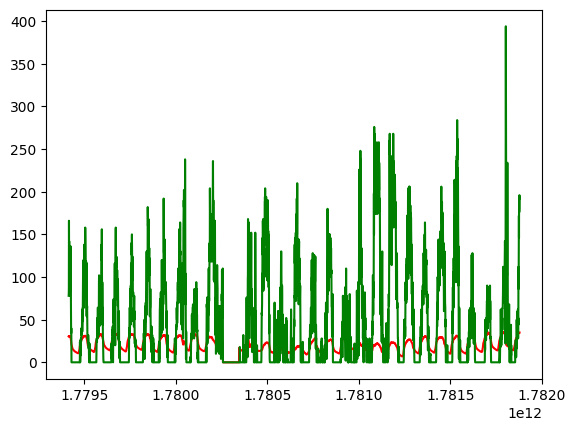

In [7]:
meteo = data[5]

ww = 28*24*6

plt.plot(meteo['time'][-ww:], meteo['temp'][-ww:],'r')
plt.plot( meteo['time'][-ww:], meteo['vent'][-ww:]*20,'g')

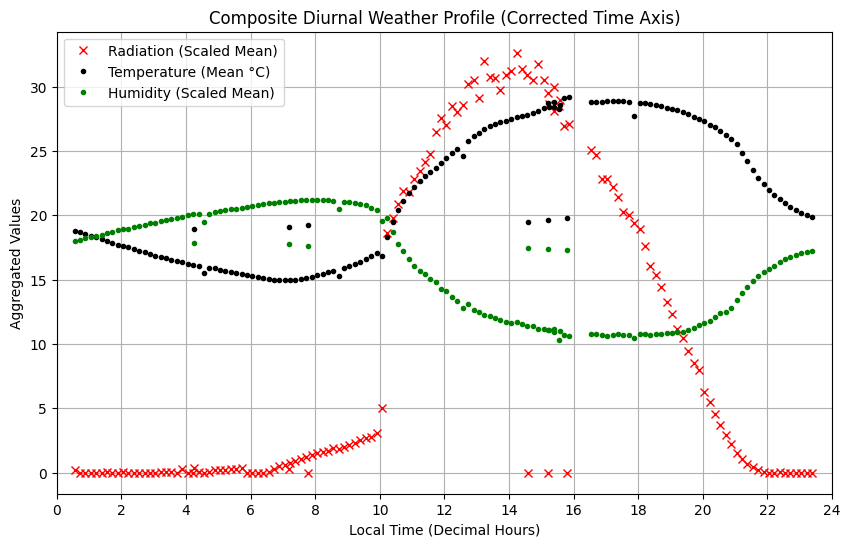

In [23]:

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import zoneinfo

# --- Setup Constants ---
INTERVALS_PER_DAY = 24 * 6  # 144 points
TOTAL_DAYS = 31
EXPECTED_SIZE = TOTAL_DAYS * INTERVALS_PER_DAY  # 4464 points

meteo = data[4]
local_tz = zoneinfo.ZoneInfo("Europe/Paris")

# --- 1. Compute a Matching Time Array for EVERY Point ---
raw_timestamps = meteo['time'][:EXPECTED_SIZE]

# Extract decimal hours for the entire dataset dynamically
all_dt_objects = [datetime.fromtimestamp(ts / 1000, tz=local_tz) for ts in raw_timestamps]
all_decimal_hours = np.array([dt.hour + dt.minute / 60.0 for dt in all_dt_objects])

# --- 2. Vectorized Daily Mean Function ---
def get_daily_mean(array_or_key):
    """
    Reshapes a flat array or a dictionary key into a (Days, Intervals) matrix 
    and returns its 24-hour mean profile across the month.
    """
    raw_array = meteo[array_or_key] if isinstance(array_or_key, str) else array_or_key
    raw_array = np.pad(raw_array, 
                       (0, max(0, EXPECTED_SIZE - len(raw_array))), 
                       mode='constant')

    grid = raw_array.reshape(TOTAL_DAYS, INTERVALS_PER_DAY)
    return np.nanmean(grid, axis=0)

# --- 3. Compute True Daily Means ---
# We now compute the average time grid alongside the weather data
mean_times = get_daily_mean(all_decimal_hours)
mean_rad   = get_daily_mean('rad')
mean_temp  = get_daily_mean('temp')
mean_hum   = get_daily_mean('hum')


# --- 4. Plotting Pipeline (Object-Oriented API) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data layers using the synchronized mean_times axis
ax.plot(mean_times, mean_rad / 25.0, 'rx', label='Radiation (Scaled Mean)')
ax.plot(mean_times, mean_temp,        'k.', label='Temperature (Mean °C)')
ax.plot(mean_times, mean_hum / 4.0,   'g.', label='Humidity (Scaled Mean)')

ax.set_xlabel('Local Time (Decimal Hours)')
ax.set_ylabel('Aggregated Values')
ax.set_title('Composite Diurnal Weather Profile (Corrected Time Axis)')
ax.set_xlim(0, 24)  # Force X-axis to standard day boundaries
ax.set_xticks(range(0, 25, 2))  # Tick marks every 2 hours
ax.legend()
ax.grid(True)

plt.show()

In [10]:
4459, 31*144, EXPECTED_SIZE


(4459, 4464, 4464)

It is incredibly satisfying when the raw physics pops right out of a clean dataset! What your student is looking at on that plot are two fundamental thermodynamic mechanisms playing out across the valley floor.

### 1. Thermal Inertia (The Radiation-Temperature Lag)

The lag between peak solar radiation and peak temperature is a classic demonstration of **thermal mass and heat transfer**.

The atmosphere doesn’t actually get heated directly by incoming shortwave solar radiation. Instead, the sun heats the earth's surface (the valley floor and the surrounding rock walls of Belledonne and Chartreuse). The ground absorbs this energy, warms up, and then heats the adjacent air via conduction and longwave thermal radiation.

This process takes time. Solar radiation peaks precisely when the sun is at its highest astronomical point (around 1:30 PM local summer time in France), but the ground and air continue to accumulate net heat for a few hours after that peak, causing the temperature to crest later in the afternoon.

```
[ Solar Noon: Radiation Peaks ] 
               │
               ▼ (Energy absorbed by valley floor)
       [ Conduction & Ground Radiative Heating ]
               │
               ▼ (Delay / Phase Lag)
[ ~2 Hours Later: Air Temperature Peaks ]

```

### 2. The Temperature-Humidity Inverse Correlation

The tight, mirror-image inverse relationship between temperature and humidity isn't actually because the air is losing water during the day; it's a consequence of how **Relative Humidity (RH)** is calculated.

Relative humidity is a ratio: how much water vapor is *actually* in the air versus the maximum amount of water vapor the air *could* hold at that specific temperature.

$$\text{RH} = \frac{\text{Actual Water Vapor (Absolute Humidity)}}{\text{Maximum Water Vapor Capacity}}$$

Because warmer air expands and its capacity to hold water vapor increases exponentially (governed by the **Clausius-Clapeyron equation**), the denominator in that equation skyrockets as the afternoon heats up. Even if the absolute amount of water vapor in the valley stays exactly the same, the *relative* humidity plummets, creating that beautiful mirror-image curve on the student's plot.

### A Great Next Step for the Student

If your student wants to prove that the water content itself isn't dropping out of the air during the day, they can use the temperature and humidity arrays to calculate the **Dew Point** or **Absolute Humidity**.

If they plot *that* metric against the time axis, they should see a relatively flat line across the 24-hour cycle—proving that while the *relative* humidity mirrors temperature perfectly, the actual moisture mass in the valley remains steady!

In [41]:
data[4]['time'].shape

(4464,)

In [26]:

import numpy as np
from datetime import datetime
import zoneinfo

TS_raw = data[4]['temp']
time_raw = data[4]['time']

INTERVALS_PER_DAY = 24 * 6  # 144 points

# --- 1. Dynamically Calculate Matrix Dimensions ---
# Figure out how many full days are in the data, plus 1 for the remaining fraction
total_points = len(TS_raw)
TOTAL_DAYS = int(np.ceil(total_points / INTERVALS_PER_DAY))
EXPECTED_SIZE = TOTAL_DAYS * INTERVALS_PER_DAY  # Exactly what we need to reshape

# --- 2. Safe Padding Execution ---
missing_points = EXPECTED_SIZE - total_points


if missing_points > 0:
    # Pad out the temperature array with NaNs
    TS = np.pad(TS_raw, (0, missing_points), constant_values=np.nan)
    
    # Pad out the timestamps by continuing the 10-minute (600000 ms) progression
    last_timestamp = time_raw[-1]
    padding_timestamps = np.array([last_timestamp + (i * 600000) 
                                   for i in range(1, missing_points + 1)])
    time_tics = np.concatenate([time_raw, padding_timestamps])
else:
    TS = TS_raw[:EXPECTED_SIZE]
    time_tics = time_raw[:EXPECTED_SIZE]

# --- 3. The Guaranteed Clean Reshape ---
temp_grid = TS.reshape(TOTAL_DAYS, INTERVALS_PER_DAY)
time_grid = time_tics.reshape(TOTAL_DAYS, INTERVALS_PER_DAY)

# --- 4. Vectorized Peak Detection ---
local_tz = zoneinfo.ZoneInfo("Europe/Paris")
peak_indices = np.nanargmax(temp_grid, axis=1)

daily_max_temps = temp_grid[np.arange(TOTAL_DAYS), peak_indices]
daily_max_times = time_grid[np.arange(TOTAL_DAYS), peak_indices]

# --- 5. Output localized results ---
hottest_times = []
for t in daily_max_times:
    dt = datetime.fromtimestamp(t / 1000, tz=local_tz)
    hottest_times.append(dt.strftime('%b %d %H:%M'))

for i, (date_str, temp) in enumerate(zip(hottest_times, daily_max_temps)):
    if np.isnan(temp):
        print(f"Day {i+1:02d}: Insufficient data for calculations.")
    else:
        print(f"Day {i+1:02d}: Peak temperature of {temp:5.2f}°C hit at {date_str}")


0 4459


ValueError: cannot reshape array of size 4459 into shape (31,144)

In [24]:
import pandas as pd

# --- 1. Convert Timestamps to Datetime Objects ---
# We convert the entire 1D array of daily max timestamps to pandas datetime objects
datetime_series = pd.to_datetime(daily_max_times, unit='ms', utc=True)

# Localize to Europe/Paris to match the physical clock of the station
localized_times = datetime_series.tz_convert('Europe/Paris')

# --- 2. Construct the Pandas DataFrame ---
df_peaks = pd.DataFrame({
    'Peak_Temp_C': daily_max_temps,
    'Peak_Time': localized_times.time,       # Extract just the HH:MM:SS
    'Date_Label': localized_times.strftime('%b %d') # Clean string representation
})

# Drop rows where data was missing (NaNs) so it doesn't pollute statistics
df_peaks.dropna(subset=['Peak_Temp_C'], inplace=True)

# Set the day counter or the date string as the index for clean alignment
df_peaks.index = range(1, len(df_peaks) + 1)
df_peaks.index.name = 'Day'

# --- 3. Display and Summary Statistics ---
df_peaks

NameError: name 'daily_max_times' is not defined


### Why this is better:

* **`np.nanargmax(axis=1)`:** This functions looks horizontally across each day row, identifies where the absolute peak temperature occurred, and returns its exact column position (from 0 to 143) instantly.
* **No Broken List Slices:** It completely bypasses the risky `zip(ts[1:], ts)` stepping loops, which are incredibly easy to break when dealing with data anomalies or incomplete historical days.
* **Preserves Local Time:** It uses your explicit `Europe/Paris` timezone conversion, ensuring that if a day peaked at 3:30 PM local French time, it accurately prints `15:30` instead of a shifted UTC value.


### Why this approach works:

* **`np.nanargmax` Protection:** Because the missing trailing values are padded with `np.nan`, `np.nanargmax` ignores them completely when finding the hottest point of the day. It won't let the artificial padding break your stats.
* **Preserves Grid Mechanics:** It safely stretches your 4,453 length array out to 4,464 so the math remains incredibly fast and vector-driven without requiring slow Python loops.

## Let's show them all in a multiplot

NameError: name 'averages' is not defined

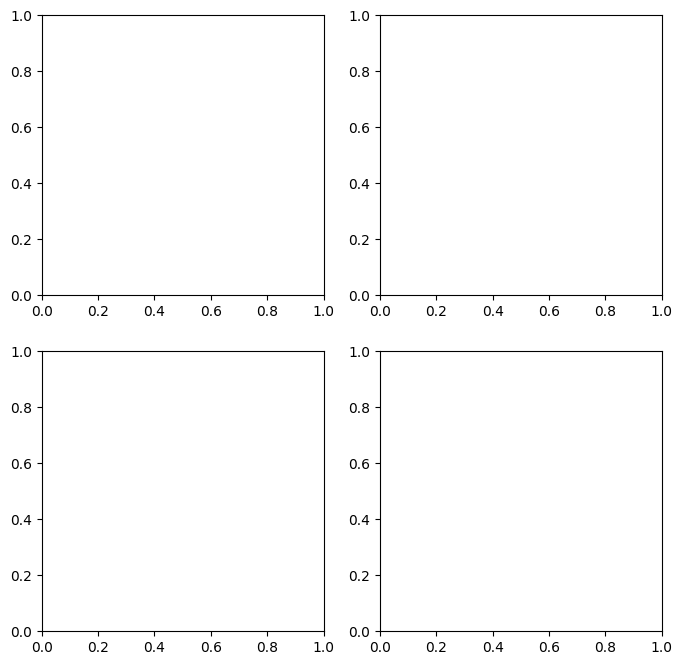

In [49]:
fig, axs = plt.subplots(2,2)
#[axi.set_axis_off() for axi in axs.ravel()]
fig.set_size_inches(8,8)

meteo = averages[3]

for k,tag in enumerate(['rafale','temp','hum','rad']):

    axs[k % 2 , k // 2].plot(times, meteo[tag],'r.')
    axs[k % 2 , k // 2].set_title(tag)
    

# Sunshine over a month

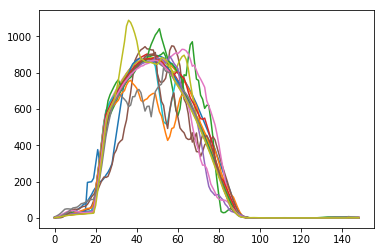

In [184]:
xx = np.copy(data[4]['rad'])
xx[xx > 2000] = 1000
xx = xx.reshape(31, len(xx)//31 )

for x in xx:
    if sum(x) < 35000: continue
    plt.plot(np.convolve(x,np.ones(6))/6 )

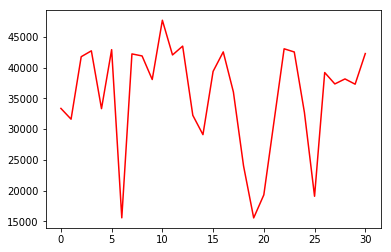

In [191]:
plt.plot([sum(x) for x in xx],'r-')

## Humidity and temperature

they seem to be correlated so let's do a linear regression to see if that is actually the case.

There might be **nan**s in the arrays so mask them out before doing the regression.

In [192]:
from scipy import stats

cors = {}
for k in [3,4,5,6,109]:
    x = data[k]
    X = np.sum( x['temp'].reshape(ndays, 24*6)/ndays, axis=0)
    Y = np.sum( x['hum'].reshape(ndays, 24*6)/ndays, axis=0)

    mask = ~(np.isnan(X) | np.isnan(Y))
    cors[k] = stats.linregress( X[mask], Y[mask])

In [193]:
cors

{3: LinregressResult(slope=-0.19110208104744422, intercept=77.13673974184037, rvalue=-0.21444092960366498, pvalue=0.010116405778747018, stderr=0.0733036838367571),
 4: LinregressResult(slope=-3.0097099747342506, intercept=130.54678025904084, rvalue=-0.9973370898886585, pvalue=2.2831382853717435e-163, stderr=0.01846896005041522),
 5: LinregressResult(slope=-3.028282245204879, intercept=134.84021286633964, rvalue=-0.993976627063515, pvalue=2.9947835834283367e-138, stderr=0.028019211801428624),
 6: LinregressResult(slope=-3.3110073718837683, intercept=137.2393557999482, rvalue=-0.9969033456491834, pvalue=1.0117975331182666e-158, stderr=0.021917338258521518),
 109: LinregressResult(slope=-2.7249459297370366, intercept=121.19107074344143, rvalue=-0.9779881901843425, pvalue=3.6240069850456903e-97, stderr=0.04913602090582902)}

### Retiming

I have to plot the data against time otherwise it's offset
so that midnight is no longer at zero.

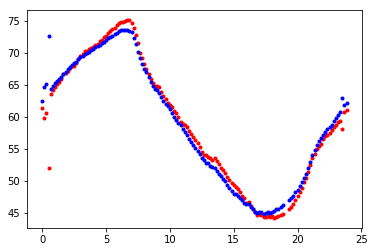

In [225]:
k = 109

vv = cors[k]
a, b = vv.slope, vv.intercept

x = data[k]
X = np.sum( x['temp'].reshape(ndays, 24*6)/ndays, axis=0)
Y = np.sum( x['hum'].reshape(ndays, 24*6)/ndays, axis=0)

plt.plot(times,Y,'r.')
#plt.plot(times,X,'g.')
plt.plot(times, a*X + b, 'b.')

## Finally calculate the time of max temperature

I checked this by hand it seems to be pretty accurate
but there is a bug with multiple days

In [43]:
len(data[4]['temp'])

31

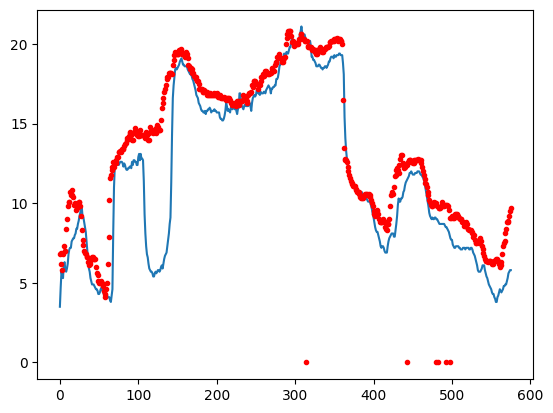

In [49]:
len_day = 6*24

plt.plot(data[4]['temp'][-len_day*9:-len_day*5])
plt.plot(data[552]['temp'][-len_day*9:-len_day*5],'r.');

## Calculate the length of a day

In [209]:
for k, y in averages.items():
    if max(y['rad']) == 0: continue
    day_light = times[y['rad'] > 4]
    print(k, max(day_light), min(day_light) )

3 21.333333333333332 6.0
5 21.333333333333332 6.166666666666667
109 21.166666666666668 6.0
4 21.333333333333332 6.166666666666667
6 21.333333333333332 6.166666666666667


In [208]:
min(averages[44]['rad'])

0.0

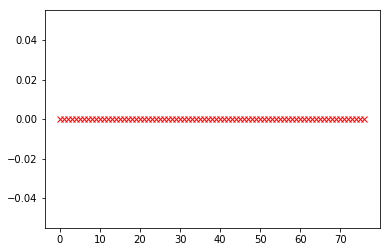

In [126]:
trans = [int(y)//1000 % (24*3600) /3600 for y in night]
trans = [ min(x,8) for x in trans ]

plt.plot(range(len(trans)),trans,'rx')

In [516]:
! ./.g


[master 300c919] web
 2 files changed, 165 insertions(+), 101 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 30.53 KiB | 976.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   991f4c4..300c919  master -> master


In [111]:
4464 - 4455

9

In [115]:
tt = get_station(ref_num=109)
meteo = html2arrays(tt)
len(meteo['time'])

4455

In [135]:
index = (meteo['time'] - meteo['time'][0])/600000 
index = index.astype(np.int32)

In [139]:
uu = np.diff(index)
sum( uu[uu > min(uu)] - min(uu) )

9

In [128]:
4464 // 24 //6

31

In [188]:
! ./.g

[master e64405b] web
 2 files changed, 18 insertions(+), 18 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 484 bytes | 121.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   a388f89..e64405b  master -> master


In [57]:
! ./.g



[master b8c191e] web
 5 files changed, 9961 insertions(+), 23 deletions(-)
 create mode 100644 romma_2026_05_22_19-30.html
 create mode 100644 romma_2026_05_22_19-30.png
 create mode 100644 romma_2026_05_22_20-13.html
 create mode 100644 romma_2026_05_22_20-13.png
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 301.91 KiB | 2.40 MiB/s, done.
Total 7 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2 local objects.
To https://github.com/macbuse/ROMMA.git
   2026ae6..b8c191e  master -> master
